# Lab 3: Mine Crafting


As with previous labs, be sure to submit only the `lab3.ipynb` and `lab3.html` version of the lab in your github `Lab3` folder. No more, and no less.

Anson Cook

May 15, 2026

## Introduction

Imagine you are a scientist for a mining company that operates a vertical mine at the Earth's
equator. This is one of the deepest mines on Earth; it's roughly 4 km to the bottom of the shaft.
Your boss proposes to measure the vertical depth of the shaft by dropping a 1 kg test mass and
accurately measuring the time to hit the bottom.

You will be guided in your investigations below and submit your report in the form of this notebook. Be sure to be quantitative in nature, produce highly polished plots, with appropriate titles, units, etc.


A table of relevant physical constants is below. Good luck!

| Quantity | Value |
|----------|-------|
|  Gravitational Constant ($G$)        |  $6.6743 \times 10^{-11}$ m$^3$/kg/s$^2$  | 
|  Gravitational Acceleration ($g_o$)  |  9.81 m/s$^2$ (approximate) | 
|  Mass of the Earth ($M_{\oplus}$)    |  $5.972 \times 10^{24}$ kg      | 
|  Mass of the Moon ($M_{m}$)          |  $7.35 \times 10^{22}$ kg     | 
|  Radius of the Earth ($R_{\oplus}$)  |  6378.1 km     | 
|  Radius of the Moon ($R_{m}$)        |   1738.1 km    | 
|  Earth's Rotation Rate at the Equator| $7.272 \times 10^{-5} $ rad/s  | 

## Part 1: The Ideal Case

In this section and the following sections, we calculate the time for the 1 kg test mass to reach the bottom of the mineshaft under a series of increasingly complex assumptions. Remember that a projectile experiencing a constant gravitational force, plus a drag force, obeys the following second
order differential equation:

$$
\frac{d^2y}{dt^2} = -g + \alpha \left| \frac{dy}{dt} \right|^{\gamma}
\tag{1}
$$



where $t$ is time, $y$ is the height, $g$ is the gravitational acceleration,
$\alpha$ is the drag coefficient, and $\gamma$ is the speed dependence
of the drag. For example, for $\gamma=2$, the drag force grows proportionally
to the speed *squared*.  **Hint**: pay particular attention to the sign
conventions in your implementation! The drag, by definition, should *oppose*
the direction of motion.

1. First, make a simple calculation of how long a test mass would 
            take to reach the bottom of the 4km shaft assuming no drag. This is the simple
            free-fall algebraic expression you know from PHYS 171.

2. Next, reduce (1) into a *system* of coupled
            first order differential equations by setting the velocity $v = dy/dt$.

3. Numerically solve (1) using `solve_ivp` assuming $\alpha=0$.
            Plot the position and velocity as a function of time.                              
            Draw a horizontal dashed line at the depth of the bottom of the shaft,
            to make it easy to see.
            Make the plot look nice, including displaying the position on the left axes,
            and plotting the velocity on a second right axis, using matplotlib `twinx`
            capability.        
   In your notebook, label this figure clearly as **Figure 1**.

4. Using the `events` detection capability of `solve_ivp`,
            calculate the time at which the mass hits the bottom of the shaft
            in the case of zero drag ($\alpha=0$). Compare this to your analytic calculation
            and discuss any differences you might see.


In [1]:
# begin by defining constants, getting necessary imports

kG = 6.6743*10**-11 # gravitational constant
kg = 9.81 # approximate gravitational acceleration at the surface of the earth
kMe = 5.972*10**24 # earth mass
kMm = 7.35*10**22 # moon mass
kRe = 6378.1*10**3 # earth radius (*10^3 to m)
kRm = 1738.1*10**3 # moon radius 1738!
kOm = 7.272*10**-5 # earth rotation rate (rad/s)

import numpy as np
import matplotlib.pyplot as plt
import scipy
scipy.__version__
from scipy.differentiate import derivative
from scipy.integrate import solve_ivp

In [2]:
# 1.1

# assuming no drag, y(t) = y(0) + y'(0)*t + (1/2)x''(0)*t^2 for constant acceleration. we assume y-independent acceleration
# and then solve for y = -4000
# (1/2)(-9.81)(t^2) = -4000

analytic_time = np.sqrt(-4000*2/-kg)
print(analytic_time) # assuming no drag

28.55686245854129


In [3]:
# 1.2

# gonna define the initial conditions so they can be tweaked later
y_init = 0
v_init = 0
a_init = -kg # defined all constants positive. i'm keeping the signs of the coordinates consistent instead of the signs of the quantities
alpha = 0
gamma = 2 # speed dependence of drag (drag ~ v^gamma)

def derivatives(t, conditions): # conditions is [position, velocity]
    assert len(conditions) == 2
    dydt = conditions[1]
    dvdt = a_init + alpha * np.abs(dydt)**gamma # drag will be making velocity less negative
    return dydt, dvdt

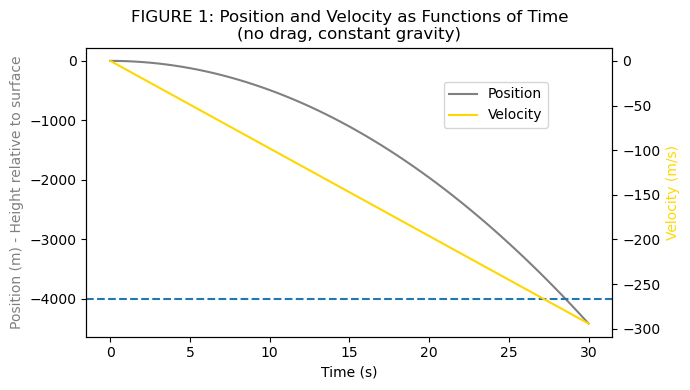

In [4]:
# 1.3

def stop_event_coffee_drinkable(t, conditions): # same event handling as in lecture 15 basically. This is processed in the below cell
    return conditions[0] + 4000

t0 = 0
tf = 30 # analytic time 28 seconds; should be v close
n = 61

times = np.linspace(t0, tf, n)
# conditions = a_init, v_init
# velocity, acceleration = dydt(times, conditions)

part_1_solution = solve_ivp(fun=derivatives, t_span=(t0,tf), y0=[y_init, v_init], t_eval=times, events=stop_event_coffee_drinkable, rtol=1e-9)

fig, position_axis = plt.subplots(figsize=(7, 4))
position_axis.set_title("FIGURE 1: Position and Velocity as Functions of Time\n(no drag, constant gravity)")
velocity_axis = position_axis.twinx()
position_axis.set_xlabel("Time (s)")
position_axis.set_ylabel("Position (m) - Height relative to surface", color='gray')
velocity_axis.set_ylabel("Velocity (m/s)", color='gold')
position_axis.plot(part_1_solution.t, part_1_solution.y[0], color='gray', label="Position")
velocity_axis.plot(part_1_solution.t, part_1_solution.y[1], color='gold', label="Velocity")

position_axis.axhline(-4000, linestyle='--')
fig.legend(bbox_to_anchor=(0.8,0.8))
fig.tight_layout()

In [5]:
# 1.4

# Using the events detection capability of solve_ivp, calculate the time at which the mass hits the bottom of the shaft
# in the case of zero drag (𝛼=0). Compare this to your analytic calculation and discuss any differences you might see.

# alpha already set to zero, event defined and accounted for in solve_ivp

numerical_time = part_1_solution.t_events[0][0]

print(f"Numerical time to reach the bottom: {numerical_time}")
print(f"Difference between numerical and analytic time: {numerical_time - analytic_time}")

print("\nThe difference between the analytic and numerical time is very, very small.")
print("This difference is independent of n (i.e. the granularity of the \"times\" linspace)")

Numerical time to reach the bottom: 28.556862458541275
Difference between numerical and analytic time: -1.4210854715202004e-14

The difference between the analytic and numerical time is very, very small.
This difference is independent of n (i.e. the granularity of the "times" linspace)


#### 1.4 Discussion

"Using the events detection capability of solve_ivp, calculate the time at which the mass hits the bottom of the shaft in the case of zero drag (𝛼=0). Compare this to your analytic calculation and discuss any differences you might see."

The numerical calculation using solve_ivp gave a fall time of ~28.56 seconds, off (under) by less than $1*10^{-14}$ from the analytical calculation.

## Part 2: Including Drag and a Variable g

In practice, we cannot ignore drag, and we should also not assume that $g$ is a constant. If you
approximate that the mass of the Earth is distributed homogenously (which it is not!), then the
gravitational constant $g$ will depend on your distance $r$ from the center of the Earth in a simple
linear way:

$$
 g(r) = g_o \left( \frac{r}{R_{\oplus}} \right)
 \tag{2}
$$

where $g_o$ is the gravity at the surface, and $R_{\oplus}$ is the radius of the Earth.

1. Make a new plot that shows the velocity and position as a function of                       
            time assuming $g(y)$. Be careful with coordinate systems!
            The test mass' position should be at the Earth radius at $t=0$, and falling down.
            But for plotting purposes, it will be useful to plot the height
            above the bottom of the shaft.        
            In your notebook, label this figure clearly as **Figure 2**.

2. What effect does incorporating a height-dependent $g$ have on the fall time? Explain.

3. Now, turn on drag, and replot the position and velocity.
            For most things, $\gamma=2$ is a good assumption.
            How can you calibrate the value of $\alpha$? Think about what we did in Lecture 15/16,
            where we assumed a sky-diver's terminal speed was 50 m/s.
            You should assume the same of the test mass.
            What affect does including drag have on the fall time?



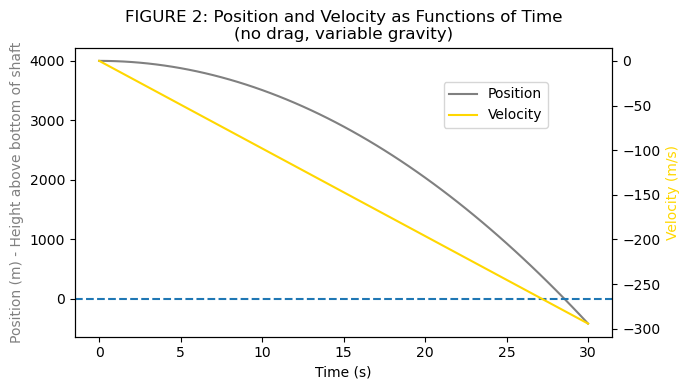

In [6]:
# 2.1

y_init = kRe # THE TEST MASS'S POSITION SHOULD BE AT THE EART RADIUS AT T = 0 AND FALLING DOWN
alpha = 0 # keep alpha set to 0 for now! part 2.1 is variable gravity, no drag
gamma = 2 # just setting these as initial values


def derivatives(t, conditions): # same as above, but a_init is not sufficient anymore as gravity is changing.
    assert len(conditions) == 2
    dydt = conditions[1]
    variant_gravity = -kg * (conditions[0]) / kRe
    dvdt = variant_gravity + alpha * np.abs(dydt)**gamma
    return dydt, dvdt

# copy-paste same process from above
def stop_event_coffee_drinkable(t, conditions): # same event handling as in lecture 15 basically. This is processed in the below cell
    # when y is kRe - 4000
    return conditions[0] + 4000 - kRe

t0 = 0
tf = 30 # analytic time 28 seconds; should be v close
n = 61

times = np.linspace(t0, tf, n)

part_2_solution = solve_ivp(fun=derivatives, t_span=(t0,tf), y0=[y_init, v_init], t_eval=times, events=stop_event_coffee_drinkable, rtol=1e-9)

fig, position_axis = plt.subplots(figsize=(7, 4))
position_axis.set_title("FIGURE 2: Position and Velocity as Functions of Time\n(no drag, variable gravity)")
velocity_axis = position_axis.twinx()
position_axis.set_xlabel("Time (s)")
# per suggestion: "it will be useful to plot the height above the bottom of the shaft"
position_axis.set_ylabel("Position (m) - Height above bottom of shaft", color='gray')
velocity_axis.set_ylabel("Velocity (m/s)", color='gold')
position_axis.plot(part_2_solution.t, part_2_solution.y[0] + 4000 - kRe, color='gray', label="Position")
velocity_axis.plot(part_2_solution.t, part_2_solution.y[1], color='gold', label="Velocity")

position_axis.axhline(0, linestyle='--')
fig.legend(bbox_to_anchor=(0.8,0.8))
fig.tight_layout()

numerical_time2 = part_2_solution.t_events[0][0]
# print(numerical_time2)

In [7]:
# 2.2 calculation

print(f"Difference between height-independent g fall time and height-dependent g fall time: {numerical_time - numerical_time2:.7f}")

# Discussion below

Difference between height-independent g fall time and height-dependent g fall time: -0.0014927


#### 2.2 Discussion

Incorporating a height-dependent g increases the fall time. The increase in fall time makes sense, as the strength of the gravitational attraction *should* decrease as there's less and less of the earth "left." More rigorously, the gravitational force F = mg is (for now) proportional to r, so the force on the mass decreases as r. It also makes sense that the difference should be small, since the height of the shaft is less than one one-thousandth of the radius of the Earth.

Time to fall: 82.32746565902305



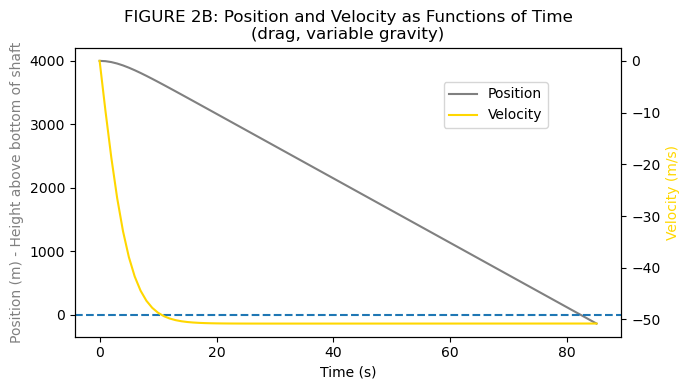

In [8]:
# 2.3

# DRAG ON! roar
# repeat above, basically
# Confirmed that neglecting lateral drag was OK

alpha = 0.0038 # plotted first then tuned until terminal speed was around 50m/s, as given
# Prof. Clark confirmed that doing this to just get a rough value was OK
gamma = 2

def derivatives(t, conditions):
    assert len(conditions) == 2
    dydt = conditions[1]
    variant_gravity = -kg * (conditions[0] / kRe)
    dvdt = variant_gravity + alpha * np.abs(dydt)**gamma
    return dydt, dvdt

def stop_event_coffee_drinkable(t, conditions):
    return conditions[0] + 4000 - kRe

t0 = 0
tf = 85 # needs to be adjusted since it'll take a lot longer now
n = 86

times = np.linspace(t0, tf, n)

part_2b_solution = solve_ivp(fun=derivatives, t_span=(t0,tf), y0=[y_init, v_init], t_eval=times, events=stop_event_coffee_drinkable, rtol=1e-9)

fig, position_axis = plt.subplots(figsize=(7, 4))
position_axis.set_title("FIGURE 2B: Position and Velocity as Functions of Time\n(drag, variable gravity)")
velocity_axis = position_axis.twinx()
position_axis.set_xlabel("Time (s)")
position_axis.set_ylabel("Position (m) - Height above bottom of shaft", color='gray')
velocity_axis.set_ylabel("Velocity (m/s)", color='gold')
position_axis.plot(part_2b_solution.t, part_2b_solution.y[0] + 4000 - kRe, color='gray', label="Position")
velocity_axis.plot(part_2b_solution.t, part_2b_solution.y[1], color='gold', label="Velocity")

position_axis.axhline(0, linestyle='--')
fig.legend(bbox_to_anchor=(0.8,0.8))
fig.tight_layout()

numerical_time2b = part_2b_solution.t_events[0][0]
print(f"Time to fall: {numerical_time2b}\n")

#### 2.3 Discussion

(calibration of alpha in code block above)

Including drag increases the fall time by about 3 times. Examining the Part 1 plots shows a scenario where the fall speed keeps increasing almost linearly which is not realistic. A skydiver with a parachute (and therefore higher drag) is going to descend more slowly than a crash dummy thrown out at the same time. Same in this case - the object eventually stops speeding up and cruises along at its terminal velocity.

## Part 3: The Coriolis Force

Since the Earth is rotating, there is a Coriolis force on the test mass as it falls.
The force can be quite large.
For example, imagine the mine shaft is on the Earth's equator and pointed towards
the Earth's center.
The equator rotates at about half a kilometer per second.
So once the test mass has fallen for some time, it will bump into the wall,
unless the shaft is very wide.
The Coriolis force $\vec{F_c}$ is:

$$
 \vec{F_c} = -2m \, \left( \vec{\Omega} \times \vec{v} \right)
 \tag{3}
$$

where $\vec{\Omega}$ is the Earth's rotation rate for a vector along $\hat{z}$ and $m$ is the mass of the object (1 kg for the test mass in this case).
For a mine shaft on the equator, we might pick a right-handed coordinate system
with the $\hat{x}$ axis along the East, $\hat{y}$ down into the mine shaft,
and $\hat{z}$ along the North.
This implies the component of the force are:

\begin{equation}
        F_{c_x} = + 2m \, \Omega v_y     \tag{4}
\end{equation}
\begin{equation}
        F_{c_y} = - 2m \, \Omega v_x     \tag{5}
\end{equation}
\begin{equation}
        F_{c_z} = 0     \tag{6}
\end{equation}

1. Extend and update your differential equations of motion 
                to include the Coriolis force. You will need to add a Coriolis
                acceleration term to your equation for the depth coordinate (remember, $F=ma$),
                and additionally, start tracking the velocity and position 
                in the transverse direction (``side-to-side'' in the shaft).

2. Plot the transverse position of the object as a function of depth, initially assuming $\alpha=0$.
                        That is, both axes will have units of distance. 
                Plot ``dots" every few seconds so that you can see
                how the particle moves over time.
                Note that your depth and transverse axes are likely to have very
                different length scales.
                The depth will have a range of 4 km,
   while the transverse direction is about 5m.       
                In your report, this should be **Figure 3**.                

3. If the mine shaft is 5m wide, and you drop the test mass 
                        from the center, does the test mass reach the bottom?
                Or does it bump into the wall first?

4. Now turn drag back on. Does drag make any difference here?




In [9]:
# 3.1

# coordinates +x = east, +y = down, +z = north
# OKed ignoring the lateral drag term

def ddt_coriolis(t, conditions): # since F_c,z = 0, we only need a 4-component vector y, x, vy, vx
    assert len(conditions) == 4
    y, x, dydt, dxdt = conditions
    
    # now that into the mineshaft is positive,
    variant_gravity = kg * (y / kRe) # gravity is acting in the POSITIVE direction
    
    # Coriolis
    # what is omega
    # just rotation rate
    # we already have that. hooray
    omega = kOm
    # we've been given components so by newton's second law, we have
    coacceleration_y = -2 * omega * dxdt
    coacceleration_x = 2 * omega * dydt
    
    # Neglecting lateral drag OK?
    dvdt_y = variant_gravity + -alpha * np.abs(dydt)**gamma + coacceleration_y
    dvdt_x = coacceleration_x
    
    return dydt, dxdt, dvdt_y, dvdt_x # vy, vx, ay, ax

def stop_event_coffee_drinkable(t, conditions):
    return conditions[0] - kRe - 4000 # down is positive now

Time to fall: 28.555390744726225



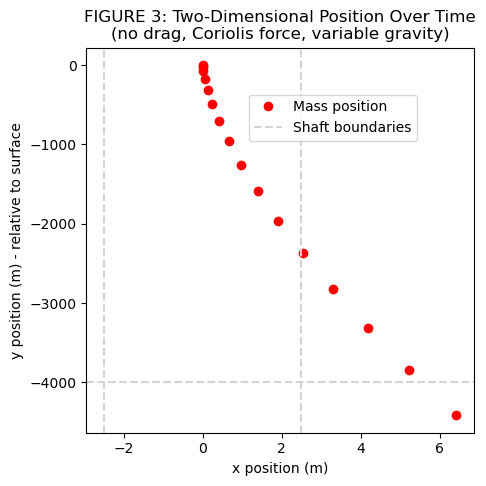

In [10]:
# 3.2

# solve without drag the first time around
initial_conditions = [kRe, 0, 0, 0]

alpha = 0
t0 = 0
tf = 30
n = 61
times = np.linspace(t0, tf, n)

part_3_solution = solve_ivp(fun=ddt_coriolis, t_span=(t0,tf), y0=initial_conditions, t_eval=times, events=stop_event_coffee_drinkable, rtol=1e-9)

fig, ax = plt.subplots(figsize=(5, 5))
ax.set_title("FIGURE 3: Two-Dimensional Position Over Time\n(no drag, Coriolis force, variable gravity)")
ax.set_xlabel("x position (m)")
ax.set_ylabel("y position (m) - relative to surface")
ax.plot(part_3_solution.y[1][::4], -(part_3_solution.y[0][::4] - kRe), 'o', color='red', label="Mass position")

ax.axhline(-4000, linestyle='--', color='lightgray', label='Shaft boundaries')
ax.axvline(-2.5, linestyle='--', color='lightgray')
ax.axvline(2.5, linestyle='--', color='lightgray')


fig.legend(bbox_to_anchor=(0.8,0.8))

numerical_time3 = part_3_solution.t_events[0][0]
print(f"Time to fall: {numerical_time3}\n")

In [11]:
# 3.3

# If the mine shaft is 5m wide, and you drop the test mass from the center
# does the test mass reach the bottom? Or does it bump into the wall first?\"\n")

print("As shown with the dashed lines in the plot above, the test mass hits the wall before reaching the bottom of the well.")

As shown with the dashed lines in the plot above, the test mass hits the wall before reaching the bottom of the well.


Yes, drag does have a noticeable effect.
Specifically, it makes the mass hit the wall sooner than it otherwise would have.
A rough estimate would be that the mass hits the wall 1100/2500 = 44% higher up than it otherwise would.


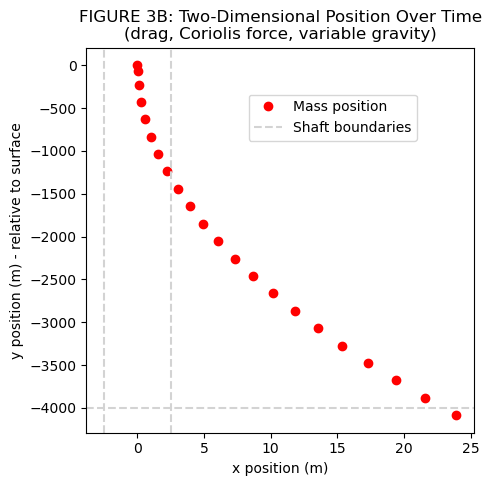

In [12]:
# 3.4

# solve with drag the second time around
alpha = 0.0038
t0 = 0
tf = 85
n = 86
times = np.linspace(t0, tf, n)

part_3b_solution = solve_ivp(fun=ddt_coriolis, t_span=(t0,tf), y0=initial_conditions, t_eval=times, events=stop_event_coffee_drinkable, rtol=1e-9)

fig, ax = plt.subplots(figsize=(5, 5))
ax.set_title("FIGURE 3B: Two-Dimensional Position Over Time\n(drag, Coriolis force, variable gravity)")
ax.set_xlabel("x position (m)")
ax.set_ylabel("y position (m) - relative to surface")
ax.plot(part_3b_solution.y[1][::4], -(part_3b_solution.y[0][::4] - kRe), 'o', color='red', label="Mass position")

ax.axhline(-4000, linestyle='--', color='lightgray', label='Shaft boundaries')
ax.axvline(-2.5, linestyle='--', color='lightgray')
ax.axvline(2.5, linestyle='--', color='lightgray')

fig.legend(bbox_to_anchor=(0.8,0.8)) # blocking text

numerical_time3b = part_3b_solution.t_events[0][0]
#print(f"Time to fall: {numerical_time3b}\n")

print("Yes, drag does have a noticeable effect.")
print("Specifically, it makes the mass hit the wall sooner than it otherwise would have.")
print("A rough estimate would be that the mass hits the wall 1100/2500 = 44% higher up than it otherwise would.")

# Confirmed don't need to get an analytic description of this

## Part 4: An infinitely deep mine


Now, let us consider the theoretical case of an infinitely deep mine -- that is,
a tunnel which traverses the full diameter of the Earth.
For convenience, imagine the tunnel goes from pole-to-pole,
such that $\vec{\Omega} \times \vec{v} = 0$, and the Coriolis force
can be neglected, as well as the drag force.

Additionally, continue assuming a constant density Earth.

1. Again, plot the depth and velocity as a function of time.
               (Be careful with the meaning of $y$, as the particle can theoretically
                traverse fully through to the other side of the Earth.)
                Comment on what you see in the graph.       
                In your notebook, label this figure clearly as **Figure 4**.                

2. How long will it take for the object to reach the other side? 
                At what time does the object reach the center of the Earth,
                and at what speed?

3. How does this ``crossing-time" compare to the orbital period, where you assume
                the object is on a circular orbit, in centripetal balance
                with the attractive force of the gravity.
                \begin{equation}
                        \frac{v^2}{R} = \frac{GM}{R^2}   \tag{7}
                \end{equation}
                gives the orbital speed $v$ for a given Earth radius $R$ and 
                Earth mass $M$.





The graph shows a simple harmonic oscillation. This is completely unsurprising, since gravity is linearly dependent on r. A linear restoring force is the definition of a simple harmonic oscillator.


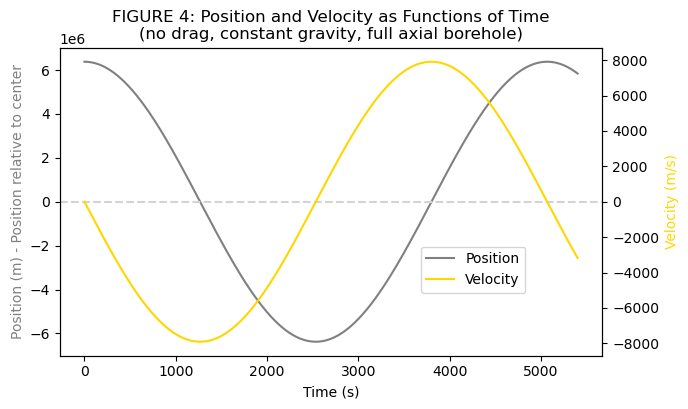

In [13]:
# 4.1

# this is really why y = kRe on the surface is preferable i guess

def derivatives(t, conditions):
    assert len(conditions) == 2
    dydt = conditions[1]
    dvdt = -kg * (conditions[0] / kRe)
    return dydt, dvdt

def stop_event_coffee_drinkable_CENTER(t, conditions):
    return conditions[0]

def stop_event_coffee_drinkable_RESURFACE(t, conditions):
    return conditions[1]
    # return conditions[0] + kRe is insufficient bc we never cross it, and it looks like we never hit it exactly either, but v = 0 is something we cross

t0 = 0
tf = 5400 # one hour was not enough
n = 601
times = np.linspace(t0, tf, n)
initial_conditions = [kRe, 0]

part_4_solution = solve_ivp(fun=derivatives, t_span=(t0,tf), y0=initial_conditions, t_eval=times, events=[stop_event_coffee_drinkable_CENTER, stop_event_coffee_drinkable_RESURFACE], rtol=1e-9)

fig, position_axis = plt.subplots(figsize=(7, 4))
position_axis.set_title("FIGURE 4: Position and Velocity as Functions of Time\n(no drag, constant gravity, full axial borehole)")
velocity_axis = position_axis.twinx()

position_axis.set_xlabel("Time (s)")
position_axis.set_ylabel("Position (m) - Position relative to center", color='gray')
velocity_axis.set_ylabel("Velocity (m/s)", color='gold')
position_axis.plot(part_4_solution.t, part_4_solution.y[0], color='gray', label="Position")
velocity_axis.plot(part_4_solution.t, part_4_solution.y[1], color='gold', label="Velocity")

position_axis.axhline(0, linestyle='--', color="lightgray")

fig.legend(bbox_to_anchor=(0.8,0.4))

print("The graph shows a simple harmonic oscillation. This is completely unsurprising, since gravity is linearly dependent on r. A linear restoring force is the definition of a simple harmonic oscillator.")

In [14]:
# 4.2

exit_when = part_4_solution.t_events[1][1]
JourniedToTheCenterOfTheEarth = part_4_solution.t_events[0][0] # had to make a jules verne reference somewhere here
center_speed = part_4_solution.y_events[0][0][1]

print(f"Time to reach the antipodal point: {exit_when:.2f} seconds")
print(f"Time to reach the center of the earth: {JourniedToTheCenterOfTheEarth:.2f} seconds")
print(f"Speed at the center of the earth: {-center_speed:.2f} m/s\n")

print(f"Half an analytical orbital period for 4.3: {2 * 0.5 * np.pi * np.sqrt(kRe**3 / (kG * kMe)):.2f}")

Time to reach the antipodal point: 2533.15 seconds
Time to reach the center of the earth: 1266.58 seconds
Speed at the center of the earth: 7910.07 m/s

Half an analytical orbital period for 4.3: 2534.69


#### 4.3 Discussion

$\text{This crossing time is within 0.1% of the analytically calculated orbital half-period (calculation in above code cell).}$

$$v^{2} = \frac{GM}{R}$$

$$\frac{2 \pi R}{T} = \sqrt{\frac{GM}{R}}$$

$$T = \frac{2 \pi R^{\frac{3}{2}}}{\sqrt{GM}}$$

$\frac{T}{2}\text{ calculated above as 2534.69}$

$\text{We can also say that the time to reach the center of the earth (with these assumptions) is one quarter of an orbital period.}$

$\tiny{i am the latex lord}$

## Part 5: A non-uniform Earth

Finally, let us consider the case of a non-uniform Earth, and continue assuming we have no drag. We know from geology
that the density increases towards the center.
It rises from about 2-3 g/cm$^3$ near the surface, to more like 13 near the center.
A simple model for the density $\rho$ as a function of distance from the center of the Earth $r$ is:

$$
\rho(r) = \rho_n \left( 1 - \frac{r^2}{R_{\oplus}^2} \right)^n   \tag{8}
$$

where $n$ is some exponent, and $\rho_n$ is a normalizing constant.
The case of $n=0$ is the constant density Earth, while $n=2$ is closer to the real value.
Note that the total mass of the Earth, $M$, must be conserved.
Since the mass is the volume integral over the density:

\begin{equation}
        M = \int_V \rho(r) dV = \int_0^{2\pi} \int_0^{\pi} \int_0^{R_{\oplus}} \rho(r) r^2 \sin \phi \, dr \, d\phi \,d\theta = 4 \pi \int_0^{R_{\oplus}} \rho(r) r^2 \, dr
        \tag{9}
\end{equation}

you will need to recompute the density constant $\rho_n$ for each case of $n>0$,
You can use the `quad` integrator for this.
Note that the analytic solution is straightforward to do by hand for $n=0$,
and still manageable for $n=1,2$.
You might consider doing that integral to make sure your method is right, 
and then you can be confident for $n>0$.

1.  Plot the normalized density profile (that is, set $\rho_n=1$) as a function of radius for $n=0, 1, 2, 9$.            
              Put them all on the same plot, with a clear legend.       
              In your notebook, label this figure clearly as **Figure 5**.

2. Now, plot the force profile as a function of radius for $n=0, 1, 2, 9$.         
                This step will show you if your normalization factor $\rho_n$
                is correct, because the surface force must be the same for all $n$.       
              In your notebook, label this figure clearly as **Figure 6**.                

3. Then, plot the position and velocity as a function of time for $n=0, 1, 2, 9$
              as you did in Figure 1/2.         
              In your notebook, label this figure clearly as **Figure 7**.              

4. For $n=0, 1, 2, 9$, compute the time to reach the center, 
                and the speed achieved there.





### Part 5, Section A (Density)

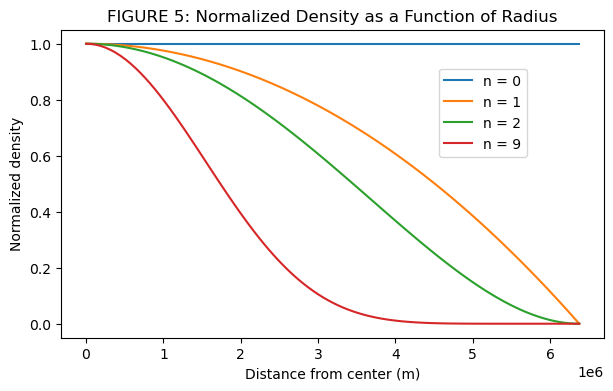

In [15]:
# 5.1

def density(r, n): # not normalized
    return (1-r**2/kRe**2)**n

def rho_n(n): # normalization factor
    # multiply by factor to make it mass of earth
    value, trash = scipy.integrate.quad(lambda r: 4 * np.pi * r**2 * density(r, n), 0, kRe)
    return kMe / value

fig, ax = plt.subplots(figsize=(7, 4))
radius_linspace = np.linspace(0, kRe, 101)

for n in [0, 1, 2, 9]:
    densities = density(radius_linspace, n) # rho_n dropped (=1)
    ax.plot(radius_linspace, densities, label=f'n = {n}')
    
ax.set_title("FIGURE 5: Normalized Density as a Function of Radius")
ax.set_xlabel("Distance from center (m)")
ax.set_ylabel("Normalized density")
    
fig.legend(bbox_to_anchor=(0.8,0.8));

### Part 5, Section B (Forces)

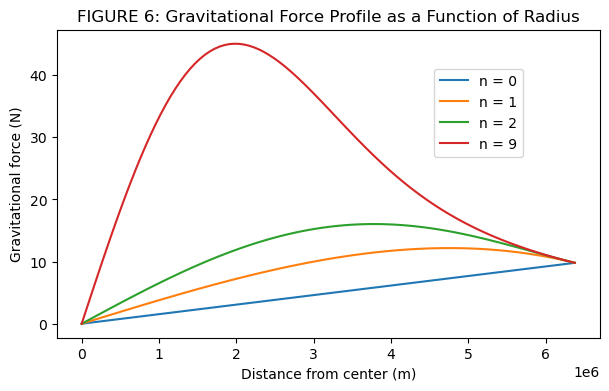

In [16]:
# 5.2

# mass -> force

fig, ax = plt.subplots(figsize=(7, 4))

def enclosed_mass(r, n, normalization_factor):
    # can't do the exact same thing since it's all the way out to the surface
    value, trash = scipy.integrate.quad(lambda s: 4 * np.pi * s**2 * density(s, n), 0, r)
    return normalization_factor * value
    
for n in [0, 1, 2, 9]:
    # Not sure if there's a cleaner way to handle this? But arrays
    forcearray = []
    rho = rho_n(n)
    for radius in radius_linspace:
        if radius == 0: # runtimewarning invalid value divide by zero
            forcearray.append(0)
        else:
            enc_m = enclosed_mass(radius, n, rho)
            forcearray.append(kG * enc_m * 1 / radius**2)
    ax.plot(radius_linspace, forcearray, label=f'n = {n}')
    
ax.set_title("FIGURE 6: Gravitational Force Profile as a Function of Radius")
ax.set_xlabel("Distance from center (m)")
ax.set_ylabel("Gravitational force (N)")

fig.legend(bbox_to_anchor=(0.8,0.8));

# surface force same for all n (~9.81N) :)

### Part 5, Section C (Equations of Motion)

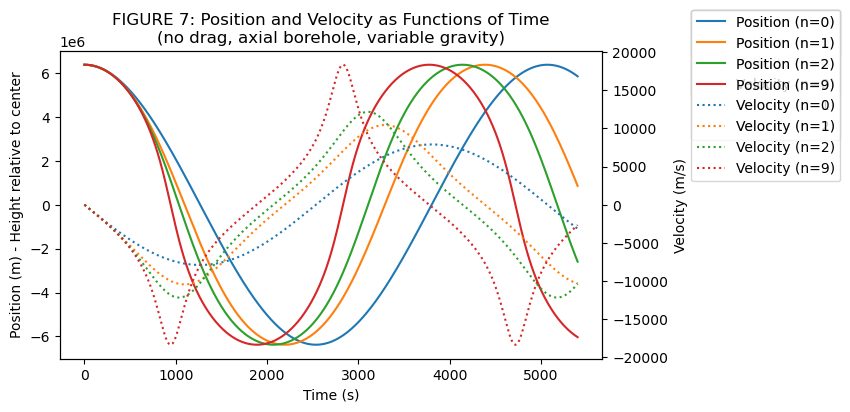

In [17]:
# 5.3

# initial conditions again
t0 = 0
tf = 5400
steps = 601 # HA FOUND IT
# CORRUPTION 
times = np.linspace(t0, tf, steps)
initial_conditions = [kRe, 0]

fig, position_axis = plt.subplots(figsize=(7, 4))
position_axis.set_title("FIGURE 7: Position and Velocity as Functions of Time\n(no drag, axial borehole, variable gravity)")
velocity_axis = position_axis.twinx()
position_axis.set_xlabel("Time (s)")
position_axis.set_ylabel("Position (m) - Height relative to center")
velocity_axis.set_ylabel("Velocity (m/s)")

timesarray = [] # filling these for 5.4
speedarray = []
part_5_solution_array = [] # could have saved here for part 7
    
for n in [0, 1, 2, 9]:
    
    def derivatives(t, conditions):
        assert len(conditions) == 2
        dydt = conditions[1]
        if conditions[0] == 0: # division by 0
            dvdt = 0
            return dydt, dvdt
        dvdt = -kG * enclosed_mass(np.abs(conditions[0]), n, rho_n(n)) * 1 / np.abs(conditions[0])**2 * (conditions[0]/np.abs(conditions[0]))
        return dydt, dvdt

    part_5_solution = solve_ivp(fun=derivatives, t_span=(t0,tf), y0=initial_conditions, t_eval=times, events=stop_event_coffee_drinkable_CENTER, rtol=1e-9)
    timesarray.append(part_5_solution.t_events[0][0])
    speedarray.append(np.abs(part_5_solution.y_events[0][0][1]))
    part_5_solution_array.append(part_5_solution)
    position_axis.plot(part_5_solution.t, part_5_solution.y[0], label=f"Position (n={n})")
    velocity_axis.plot(part_5_solution.t, part_5_solution.y[1], label=f"Velocity (n={n})", linestyle=":")
    
    fig.legend(bbox_to_anchor=(1.25,1));


In [18]:
# 5.4

# compute time to reach the center and speed at the center for the four ns
# computation done in 5.3

narray = [0, 1, 2, 9]

for i in range(4):
    print(f"Time to reach the center (s) for n = {narray[i]}: {timesarray[i]:.2f}")
    print(f"Speed at the center (m/s) for n = {narray[i]}: {speedarray[i]:.2f}\n")
    

Time to reach the center (s) for n = 0: 1267.34
Speed at the center (m/s) for n = 0: 7905.28

Time to reach the center (s) for n = 1: 1096.51
Speed at the center (m/s) for n = 1: 10457.70

Time to reach the center (s) for n = 2: 1035.08
Speed at the center (m/s) for n = 2: 12182.85

Time to reach the center (s) for n = 9: 943.78
Speed at the center (m/s) for n = 9: 18370.67



## Part 6: A Lunar Mine Shaft


Finally, with all of the framework in place, consider the case where the
the mine shaft is instead dug on the moon.

1. Compute the travel time to the center of the moon
                in case we dig a pole-to-pole mine shaft,
                so that we can again avoid the Coriolis force, though
                on the moon this force is very small. No drag force either,
   which is actually realistic for the moon!
3. What is the density (if you asssume a constant density) 
                of the moon compared to that of earth? 
4. How does the fall/orbit time depend on density? See if you can discover a 
        relationship between the density and the fall time. You should think beyond strictly linear 
        relationships.



This problem can actually be
done on paper, and then you can compare the answer with that for the homogenous earth
you did in Part 4.


In [19]:
# 6.1

time_to_center = 2 * 0.25 * np.pi * np.sqrt(kRm**3 / (kG * kMm)) # 1/4 orbital period as determined in part 4
print(f"analytical orbit-based time to center: {time_to_center:.2f}")

# CHECK with solve_ivp

def moon_derivatives(t, conditions):
    assert len(conditions) == 2
    dydt = conditions[1]
    dvdt = -kG * kMm * (conditions[0] / kRm) / kRm**2
    return dydt, dvdt

t0 = 0; tf = 5400; n = 601; times = np.linspace(t0, tf, n)
part_4_solution = solve_ivp(fun=moon_derivatives, t_span=(t0,tf), y0=[kRm, 0], t_eval=times, events=[stop_event_coffee_drinkable_CENTER, stop_event_coffee_drinkable_RESURFACE], rtol=1e-9)

print(f"Check: solve_ivp time to center: {part_4_solution.t_events[0][0]:.2f}")

analytical orbit-based time to center: 1625.12
Check: solve_ivp time to center: 1625.12


In [20]:
# 6.2

# density = mass/volume =
print(f"Moon density: {kMm/((4/3)*np.pi*kRm**3):.2f} kg/m^3 (assumed constant)")
print(f"Earth density: {kMe/((4/3)*np.pi*kRe**3):.2f} kg/m^3 (assumed constant)\n")

print("Compared to Earth, the Moon is about 40% less dense.")

Moon density: 3341.75 kg/m^3 (assumed constant)
Earth density: 5494.87 kg/m^3 (assumed constant)

Compared to Earth, the Moon is about 40% less dense.


#### 6.3 Discussion
If we want to find an expression for fall time in terms of density (assumed constant), we can substitute a rho expression in for mass:

$$M=\rho (\frac{4}{3} \pi r^3)$$

$$\text{Fall time}=2(0.25)(\pi)\sqrt{\frac{r^3}{G \rho (\frac{4}{3} \pi r^3)}}$$

$$\text{Fall time}=0.5(\pi)\sqrt{\frac{1}{G \rho (\frac{4}{3} \pi)}}$$

Therefore the fall time, which is proportional to the orbit time, scales as density to the negative one-half power (1/sqrt(rho)).

1/sqrt(rho) ratio (Moon : Earth) ~= 1/sqrt(0.61) ~= 1.28 (some decimal precision lost)

1625.12/1.28 ~= 1269.63, agreeing with our Part 4, homogeneous Earth result.

## Part 7: Fourier Transforming Orbits

Take the solutions for n=0 and n=9 of the orbits in Part 5 (the inhomogeneous earth) and Fourier Transform them, to see what frequencies (*1/periods*) are dominant in the power spectra. Comment on what you see.

**Hint:** you could take the orbit from the previous integration in Part 5c, but it is useful to increase the integration time and sampling to get more meaningful smooth enough curves. We discussed this in class.

For an example of a spectral analysis of galactic orbits see https://articles.adsabs.harvard.edu/pdf/1982ApJ...252..308B

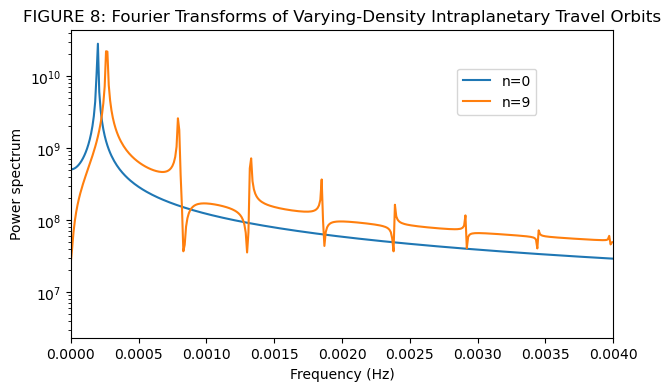

In [21]:
t0 = 0
tf = 100000
steps = 10000 # 1x per 10 sec?
times = np.linspace(t0, tf, steps)
initial_conditions = [kRe, 0]

part_7_solution_array = [] #
fig, ax = plt.subplots(figsize = (7, 4))


for i in [0, 3]:
    
    rho = rho_n(narray[i])
    
    def derivatives(t, conditions):
        assert len(conditions) == 2
        dydt = conditions[1]
        if conditions[0] == 0: # division by 0
            dvdt = 0
            return dydt, dvdt
        dvdt = -kG * enclosed_mass(np.abs(conditions[0]), narray[i], rho * 1 / np.abs(conditions[0])**2 * (conditions[0]/np.abs(conditions[0])))
        return dydt, dvdt
    
    part_7_solution = solve_ivp(fun=derivatives, t_span=(t0,tf), y0=initial_conditions, t_eval=times, rtol=1e-12)
    signal = part_7_solution.y[0]

    frequencies = np.fft.rfftfreq(len(signal), d=(tf-t0)/steps)
    fourier_values = np.fft.rfft(signal)
    
    ax.plot(frequencies, np.abs(fourier_values), label=f"n={narray[i]}") # power spectrum
    ax.set_xlim(0, 0.004)
    ax.set_yscale("log") # can be left out; same defining characteristics visible regardless of linear or log
    
ax.set_title("FIGURE 8: Fourier Transforms of Varying-Density Intraplanetary Travel Orbits")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Power spectrum")

fig.legend(bbox_to_anchor=(0.8,0.8));
    
#print(part_7_solution)

#fig2, ax2 = plt.subplots()
#ax2.plot(times, signal) # diagnosed loss of numerical precision issue

#### 7.1 Discussion

The n=0 curve above has one distinct, sharp peak, indicating just one fundamental frequency in the "orbit" of the mass falling along the constant-density borehole (i.e. simple harmonic oscillation). As discussed above, the constant density and implied linear restoring force explain this.

The n=9 curve is more complex. There is also one dominant peak, this one at a slightly higher frequency than the n=0 peak. This manifests as a faster fall time (calculated in part 5). There are also several smaller, secondary peaks. These secondary frequencies are what modify the axial oscillation from simple harmonic oscillation to the shape of the plot in 5.3.
